# How to add short-term plasticity

**Task.** Model use-dependent synapses whose efficacy changes on a fast
timescale — short-term facilitation (`STP`) and short-term depression (`STD`).

**Audience.** Simulation. Assumes {doc}`../tutorials/02-synapse-and-projection`.

Short-term plasticity makes a synapse's strength depend on its recent activity.
`brainpy.state` provides two models you can drive directly:

- **`STP`** — the Tsodyks–Markram model with both facilitation and depression,
  tracking a utilization variable `u` and a resources variable `x`. The
  effective release is proportional to `u · x`.
- **`STD`** — pure depression, tracking the resources `x`.

Here we examine their dynamics in isolation: drive each with a regular spike
train and watch the internal variables and the resulting efficacy evolve. This
is the clearest way to understand what each model does before wiring it into a
projection.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A regular presynaptic spike train

We build a 20 Hz spike train over 400 ms (one spike every 50 ms).

In [2]:
with brainstate.environ.context(dt=0.1 * u.ms):
    times = u.math.arange(0. * u.ms, 400. * u.ms, brainstate.environ.get_dt())
    t_ms = times.to_decimal(u.ms)
    # a spike whenever the time is (almost) a multiple of 50 ms
    spike_train = (u.math.asarray((t_ms % 50.0) < 0.05)).astype(float)

## Short-term facilitation + depression (`STP`)

`STP.update(pre_spike)` advances `u` and `x` and returns the modulated efficacy.
With a long facilitation time constant, `u` ramps up across the train while `x`
is drawn down — the product `u·x` shows the net synaptic efficacy.

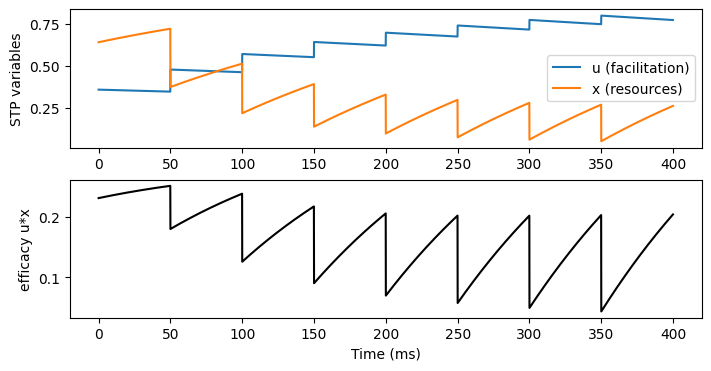

In [3]:
with brainstate.environ.context(dt=0.1 * u.ms):
    stp = brainpy.state.STP(1, U=0.2, tau_f=1500. * u.ms, tau_d=200. * u.ms)
    brainstate.nn.init_all_states(stp)

    def step_stp(sp):
        eff = stp(sp)
        return eff, stp.u.value, stp.x.value

    eff_stp, u_var, x_var = brainstate.transform.for_loop(step_stp, spike_train)

fig, gs = braintools.visualize.get_figure(2, 1, 1.8, 7.0)
ax = fig.add_subplot(gs[0, 0])
ax.plot(t_ms, u_var[:, 0], label='u (facilitation)')
ax.plot(t_ms, x_var[:, 0], label='x (resources)')
ax.legend(loc='center right'); ax.set_ylabel('STP variables')
ax = fig.add_subplot(gs[1, 0])
ax.plot(t_ms, (u_var * x_var)[:, 0], color='k')
ax.set_ylabel('efficacy u*x'); ax.set_xlabel('Time (ms)')
plt.show()

## Short-term depression (`STD`)

`STD` tracks only the resources `x`, which deplete with each spike and recover
with time constant `tau`. Successive spikes in the train produce progressively
weaker responses.

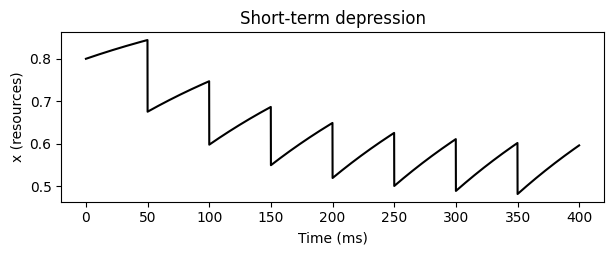

In [4]:
with brainstate.environ.context(dt=0.1 * u.ms):
    std = brainpy.state.STD(1, tau=200. * u.ms, U=0.2)
    brainstate.nn.init_all_states(std)

    def step_std(sp):
        eff = std(sp)
        return eff, std.x.value

    eff_std, x_std = brainstate.transform.for_loop(step_std, spike_train)

plt.figure(figsize=(7, 2.2))
plt.plot(t_ms, x_std[:, 0], color='k')
plt.ylabel('x (resources)'); plt.xlabel('Time (ms)')
plt.title('Short-term depression')
plt.show()

## Using STP/STD in a projection

To make a *projection* dynamic, the functional projection builders accept an
`stp=` describer, e.g.::

    brainpy.state.align_post_projection(
        pre.prefetch('V'),
        lambda v: pre.get_spike(v) != 0.,
        comm=brainstate.nn.EventFixedProb(n_pre, n_post, 0.1, w),
        syn=brainpy.state.Expon.desc(n_post, tau=5. * u.ms),
        out=brainpy.state.COBA.desc(E=0. * u.mV),
        post=post,
        stp=brainpy.state.STP.desc(n_pre, U=0.2, tau_f=1500. * u.ms, tau_d=200. * u.ms),
    )

## See also

- {doc}`/apis/brainpy-plasticity` — `STP` and `STD` reference.
- {doc}`sim-delays` — add transmission delays to a projection.
- {doc}`/concepts/alignpre-alignpost` — how projections route presynaptic state.